In [1]:
# https://gemini.google.com/app/5109b1ed662b462a


import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)


# %%
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist


# Base parameters for PMOS and NMOS
stdp_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation()+1,
        "routing_metal": "met2",
        "dummy_devices": False,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False
}

pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False
}

In [2]:

pdk = gf180
stdp_comp = Component(name="stdp")
stdp_comp.name = "stdp"
rules = stdp_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]

# =========================================================================
# 1. INSTANTIATE ALL DEVICES MATCHING SPICE NETLIST
# =========================================================================

# --- PMOS TRANSISTORS ---
# XM1: W=0.22u, L=0.28u -> w=0.5 L=0.63 
xm1 = pmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM2: W=0.22u, L=0.28u
xm2 = pmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM7: W=0.22u, L=0.28u
xm7 = pmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM8: W=0.22u, L=0.28u
xm8 = pmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM17: W=0.3u, L=4.6u
xm17 = pmos(pdk, width=0.5, length=4.6, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM16: W=10.2u, L=2.8u
xm16 = pmos(pdk, width=10.2, length=2.8, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

# --- NMOS TRANSISTORS ---
# XM3: W=0.22u, L=0.28u
xm3 = nmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XM4: W=0.22u, L=0.28u
xm4 = nmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XM9: W=0.22u, L=0.28u
xm9 = nmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XM12: W=0.22u, L=0.28u
xm12 = nmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XMCM_1: W=0.61u, L=2.8u
xmcm_1 = nmos(pdk, width=0.61, length=2.8, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)

# --- LONG-CHANNEL BIAS CHAIN (XMCM_5 to XMCM_9): W=0.5u, L=10u ---
xmcm_chain = [
    nmos(pdk, width=0.5, length=10.0, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
    for _ in range(5)
]


# --- MIM CAPACITORS ---
# Cpot: 5x5um, m=2 (2 rows, 1 col)
cpot = mimcap_array(pdk, size=(5, 5), rows=2, columns=1)
# Cdep: 5x5um, m=2 (2 rows, 1 col)
cdep = mimcap_array(pdk, size=(5, 5), rows=2, columns=1)
# Cw: 5x5um, m=10 (2 rows, 5 cols)
cw = mimcap_array(pdk, size=(5, 5), rows=5, columns=2)


xm1.name = "xm1" 
xm2.name = "xm2" 
xm7.name = "xm7" 
xm8.name = "xm8" 
xm17.name = "xm17" 
xm16.name = "xm16" 
xm3.name = "xm3"
xm4.name = "xm4"
xm9.name = "xm9"
xm12.name = "xm12"
xmcm_1.name = "xmcm_1"
xmcm_chain[0].name = "xmcm_chain_0"
xmcm_chain[1].name = "xmcm_chain_1"
xmcm_chain[2].name = "xmcm_chain_2"
xmcm_chain[3].name = "xmcm_chain_3"
xmcm_chain[4].name = "xmcm_chain_4"
cpot.name = "cpot" 
cdep.name = "cdep" 
cw.name = "cw" 


# =========================================================================
# 2. PLACEMENT & FLOORPLANNING
# =========================================================================

# Add components to subcircuit
#top row
xm1_ref = stdp_comp << xm1
xm2_ref = stdp_comp << xm2
xm7_ref = stdp_comp << xm7
xm8_ref = stdp_comp << xm8
xm17_ref = stdp_comp << xm17
xm16_ref = stdp_comp << xm16


# second row
xm3_ref = stdp_comp << xm3
xm4_ref = stdp_comp << xm4
xm9_ref = stdp_comp << xm9
xm12_ref = stdp_comp << xm12
xmcm_1_ref = stdp_comp << xmcm_1
chain_refs = [stdp_comp << dev for dev in xmcm_chain]

cpot_ref = stdp_comp << cpot
cdep_ref = stdp_comp << cdep
cw_ref = stdp_comp << cw



#placement of three rows
bottom_row_y = evaluate_bbox(chain_refs[1])[1]/2 + 4
middle_row_y = bottom_row_y + evaluate_bbox(chain_refs[0])[1]
top_row_y = middle_row_y + evaluate_bbox(xmcm_1)[1] + evaluate_bbox(xm16)[1]/2
# --- TOP ROW: PMOS Array ---
xm1_xy = evaluate_bbox(xm1)
xm2_xy = evaluate_bbox(xm2)
xm7_xy = evaluate_bbox(xm7)
xm8_xy = evaluate_bbox(xm8)
xm17_xy = evaluate_bbox(xm17)
xm16_xy = evaluate_bbox(xm16)
cpot_xy = evaluate_bbox(cpot)
xm1_ref.move((0 + xm1_xy[0]/2, top_row_y ))
xm2_ref.move((xm1_ref.xmax + xm2_xy[0]/2 + spacing, top_row_y))
xm7_ref.move((xm2_ref.xmax + xm7_xy[0]/2 + spacing, top_row_y))
xm8_ref.move((xm7_ref.xmax + xm8_xy[0]/2 + spacing, top_row_y))
xm17_ref.move((xm8_ref.xmax + xm17_xy[0]/2 + spacing, top_row_y))
xm16_ref.move((xm17_ref.xmax + xm16_xy[0]/2 + spacing, top_row_y))


# --- MIDDLE ROW: Standard NMOS Array ---
xm3_xy = evaluate_bbox(xm3)
xm4_xy = evaluate_bbox(xm4)
xm9_xy = evaluate_bbox(xm9)
xm12_xy = evaluate_bbox(xm12)
xmcm_1_xy = evaluate_bbox(xmcm_1)
cdep_xy = evaluate_bbox(cdep)

xm3_ref.move((0 + xm3_xy[0]/2, middle_row_y+ spacing))
xm4_ref.move((xm3_ref.xmax + xm4_xy[0]/2 + spacing, middle_row_y+ spacing))
xm9_ref.move((xm4_ref.xmax + xm9_xy[0]/2 + spacing, middle_row_y+ spacing))
xm12_ref.move((xm9_ref.xmax + xm12_xy[0]/2 + spacing, middle_row_y+ spacing))
xmcm_1_ref.move((xm12_ref.xmax + xmcm_1_xy[0]/2 + spacing, middle_row_y + spacing))
chain_refs[0].move((xmcm_1_ref.xmax + evaluate_bbox(chain_refs[0])[0]/2 + spacing, middle_row_y + spacing))

# --- BOTTOM ROW: Long-Channel Bias Chain (Series connected) ---
chain_refs[1].move((evaluate_bbox(chain_refs[1])[0]/2, bottom_row_y))
chain_refs[2].move((chain_refs[1].xmax + evaluate_bbox(chain_refs[2])[0]/2 + spacing, bottom_row_y))
chain_refs[3].move((chain_refs[2].xmax + evaluate_bbox(chain_refs[3])[0]/2 + spacing, bottom_row_y))
chain_refs[4].move((chain_refs[3].xmax + evaluate_bbox(chain_refs[4])[0]/2 + spacing, bottom_row_y))


# --- MOVING CAPACITORS: 
cw_xy = evaluate_bbox(cw)
cpot_ref.move((xm16_ref.xmax + cpot_xy[0]/2 + 1.5, top_row_y-4))
cdep_ref.move((cpot_ref.xmax + cdep_xy[0]/2 + 1.5, top_row_y-4))
cw_ref.move((cdep_ref.xmax + cdep_xy[0]/2 + 4, bottom_row_y))

2026-08-10 21:07:16.917 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


ComponentReference (parent Component "cw", ports ['row0_col0_array_row0_col0_bottom_layer_W', 'row0_col0_array_row0_col0_bottom_via_W', 'row0_col0_array_row0_col0_bottom_met_W', 'row0_col0_array_row0_col0_top_met_W', 'row0_col0_array_row0_col1_bottom_layer_W', 'row0_col0_array_row0_col1_bottom_via_W', 'row0_col0_array_row0_col1_bottom_met_W', 'row0_col0_array_row0_col1_top_met_W', 'row0_col0_array_row0_col2_bottom_layer_W', 'row0_col0_array_row0_col2_bottom_via_W', 'row0_col0_array_row0_col2_bottom_met_W', 'row0_col0_array_row0_col2_top_met_W', 'row0_col0_array_row0_col3_bottom_layer_W', 'row0_col0_array_row0_col3_bottom_via_W', 'row0_col0_array_row0_col3_bottom_met_W', 'row0_col0_array_row0_col3_top_met_W', 'row0_col1_array_row0_col0_bottom_layer_W', 'row0_col1_array_row0_col0_bottom_via_W', 'row0_col1_array_row0_col0_bottom_met_W', 'row0_col1_array_row0_col0_top_met_W', 'row0_col1_array_row0_col1_bottom_layer_W', 'row0_col1_array_row0_col1_bottom_via_W', 'row0_col1_array_row0_col1_bo

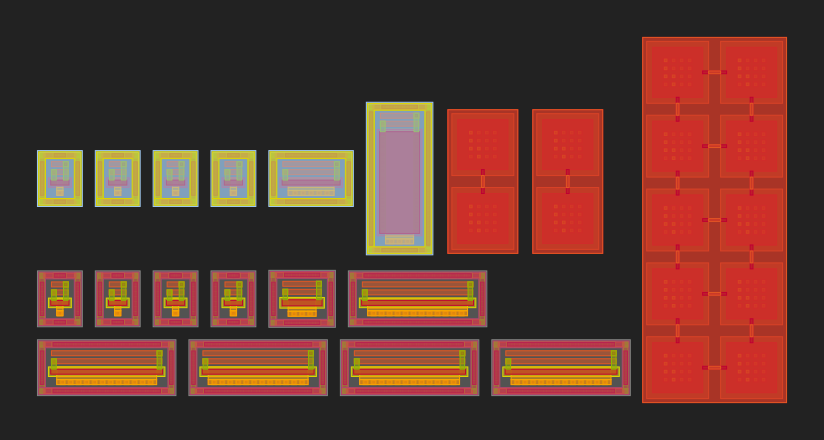

In [3]:
# stdp_comp.show()
display_component(stdp_comp, scale = 1,path=".")

In [4]:
# =========================================================================
# 4. ADD AVDD & AVSS POWER RAILS AND CONNECT SUPPLY NODES
# =========================================================================

# https://gemini.google.com/app/131a537106def8cd
# Calculate full horizontal span of the cell to draw supply rails
bbox = evaluate_bbox(stdp_comp)
top_y = stdp_comp.ymax + 3.0
bottom_y = stdp_comp.ymin - 3.0

# Draw horizontal metal2 power rails
avdd_rail = stdp_comp << gf.components.rectangle(
    size=(bbox[0]+4, 1.0), 
    layer=pdk.get_layer("metal2")
)
avdd_rail.move((-2, top_y))

avss_rail = stdp_comp << gf.components.rectangle(
    size=(bbox[0]+4, 1.0), 
    layer=pdk.get_layer("metal2")
)
avss_rail.move((-2, bottom_y))

# Add global ports for the supply rails
stdp_comp.add_port("avdd", center=(bbox[0]/2, top_y + 0.5), width=1.0, orientation=180, layer=pdk.get_layer("metal2"), port_type="electrical")
stdp_comp.add_port("avss", center=(bbox[0]/2, bottom_y + 0.5), width=1.0, orientation=180, layer=pdk.get_layer("metal2"), port_type="electrical")
# add label to those global ports 
stdp_comp.add_label(text="avdd", position=(bbox[0]/2, top_y + 0.5), layer=pdk.get_glayer("met2_label") , magnification=1.5)
stdp_comp.add_label(text="avss", position=(bbox[0]/2, bottom_y + 0.5), layer=pdk.get_glayer("met2_label") , magnification=1.5)


Label(text='avss', origin=(37.49, 0.7999999999999998), layer=(36, 10))

In [5]:
# =========================================================================
# 3. ROUTING & NET CONNECTIONS
# =========================================================================
# https://gemini.google.com/app/131a537106def8cd
# Gemini commited plenty of error in LVS. We have to modify each connection
# Connect PMOS sources to avdd rail
stdp_comp << L_route(pdk, xm1_ref.ports["tie_W_top_met_N"], stdp_comp.ports["avdd"])
stdp_comp << L_route(pdk, xm2_ref.ports["tie_W_top_met_N"], stdp_comp.ports["avdd"])
stdp_comp << L_route(pdk, xm7_ref.ports["tie_W_top_met_N"], stdp_comp.ports["avdd"])
stdp_comp << L_route(pdk, xm8_ref.ports["tie_W_top_met_N"], stdp_comp.ports["avdd"])
stdp_comp << L_route(pdk, xm17_ref.ports["tie_W_top_met_N"], stdp_comp.ports["avdd"])
stdp_comp << L_route(pdk, xm16_ref.ports["tie_W_top_met_N"], stdp_comp.ports["avdd"])
# Connect NMOS BULKS TO AVSS
stdp_comp << L_route(pdk, chain_refs[1].ports["tie_W_top_met_S"], stdp_comp.ports["avss"])
stdp_comp << L_route(pdk, chain_refs[2].ports["tie_W_top_met_S"], stdp_comp.ports["avss"])
stdp_comp << L_route(pdk, chain_refs[3].ports["tie_W_top_met_S"], stdp_comp.ports["avss"])
stdp_comp << L_route(pdk, chain_refs[4].ports["tie_W_top_met_S"], stdp_comp.ports["avss"])
stdp_comp << straight_route(pdk, xm3_ref.ports["tie_W_top_met_S"], chain_refs[1].ports["tie_W_top_met_N"]) # Tie all the transistor's bulk of the middle row together,
stdp_comp << straight_route(pdk, xm3_ref.ports["tie_S_top_met_E"], chain_refs[0].ports["tie_S_top_met_W"]) #  then sending one connection to vdd

# Connect MIM Capacitor Ground plates to avss
stdp_comp << straight_route(pdk, cw_ref.ports["row0_col0_bottom_met_S"], stdp_comp.ports["avss"])
stdp_comp << straight_route(pdk, cdep_ref.ports["row0_col0_bottom_met_E"], cw_ref.ports["row2_col0_bottom_met_S"])

#connect MIM Capacitor Cpot plate to avdd
stdp_comp << straight_route(pdk, cpot_ref.ports["row1_col0_array_row0_col3_top_met_N"], stdp_comp.ports["avdd"])
# Connecting the corresponding PMOS sources to avdd
stdp_comp << straight_route(pdk,  xm1_ref.ports["multiplier_0_source_W"], xm1_ref.ports["tie_W_top_met_N"])  # SOURCE XM1
stdp_comp << straight_route(pdk,  xm16_ref.ports["multiplier_0_source_W"], xm16_ref.ports["tie_W_top_met_N"])   # SOURCE XM16
stdp_comp << straight_route(pdk,  xm17_ref.ports["multiplier_0_source_W"], xm17_ref.ports["tie_W_top_met_N"]) # SOURCE XM17
stdp_comp << straight_route(pdk,  xm7_ref.ports["multiplier_0_source_W"], xm7_ref.ports["tie_W_top_met_N"]) # SOURCE XM7

# Connecting the corresponding NMOS SOURCES TO AVSS
stdp_comp << straight_route(pdk,  xm9_ref.ports["multiplier_0_source_W"], xm9_ref.ports["tie_W_top_met_N"]) #xm9
stdp_comp << straight_route(pdk,  chain_refs[4].ports["multiplier_0_source_W"], chain_refs[4].ports["tie_W_top_met_N"]) #chain[4]
stdp_comp << straight_route(pdk,  xm4_ref.ports["multiplier_0_source_W"], xm4_ref.ports["tie_W_top_met_N"]) #xm4
stdp_comp << straight_route(pdk,  xmcm_1_ref.ports["multiplier_0_source_W"], xmcm_1_ref.ports["tie_W_top_met_N"]) #xmcm1

ComponentReference (parent Component "straight_route_3e7c72c9", ports ['route_W', 'route_N', 'route_E', 'route_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

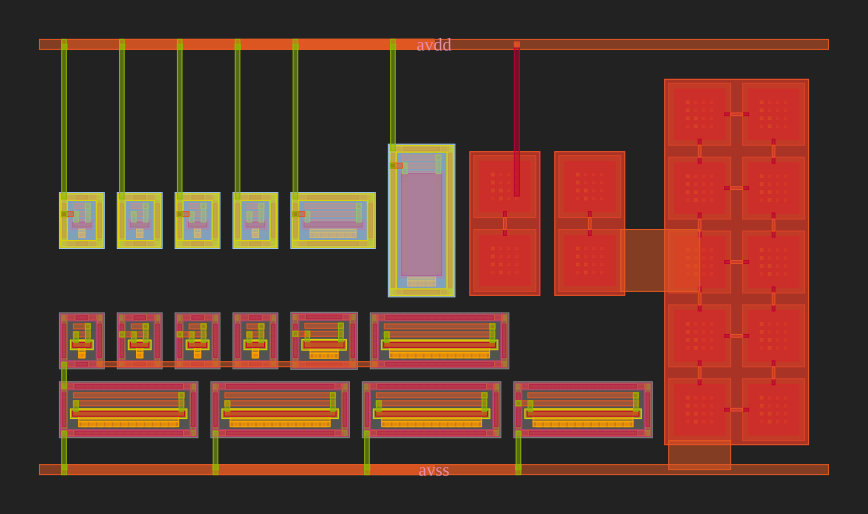

In [6]:
# stdp_comp.show()
display_component(stdp_comp, scale = 1,path=".")

In [7]:

# --- B. INTERNAL NET ROUTING ---
# net1: XM1 Drain -> XM2 Source
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
xm1_xm2_via = stdp_comp << viam2m3
xm1_xm2_via.move(xm1_ref.ports["multiplier_0_drain_E"].center).movex(2).movey(-5)
stdp_comp << c_route(pdk, xm1_ref.ports["multiplier_0_drain_W"], xm1_xm2_via.ports["bottom_met_W"], extension=1.5)
stdp_comp << L_route(pdk, xm1_xm2_via.ports["top_met_N"],xm2_ref.ports["multiplier_0_source_W"])


# net2: XM3 Source -> XM4 Drain
xm3_xm4_via = stdp_comp << viam2m3
xm3_xm4_via.move(xm3_ref.ports["multiplier_0_source_E"].center).movex(2)
stdp_comp << straight_route(pdk, xm3_ref.ports["multiplier_0_source_E"], xm3_xm4_via.ports["bottom_met_W"])
stdp_comp << L_route(pdk, xm3_xm4_via.ports["top_met_N"], xm4_ref.ports["multiplier_0_drain_W"])


# net3: XM7 Drain -> XMCM_1 Drain
xm7_xmcm_via = stdp_comp << viam2m3
xm7_xmcm_via.move(xm7_ref.ports["multiplier_0_drain_E"].center).movex(8).movey(-5)
stdp_comp << c_route(pdk, xm7_xmcm_via.ports["bottom_met_W"], xm7_ref.ports["multiplier_0_drain_W"], extension=2)
stdp_comp << L_route(pdk, xm7_xmcm_via.ports["top_met_S"], xmcm_1_ref.ports["multiplier_0_drain_W"])

# net4: XM7 Gate -> XM8 Drain
xm7g_xm8d_via = stdp_comp << viam2m3
xm7g_xm8d_via.move(xm7_ref.ports["multiplier_0_gate_S"].center).movey(-0.8)
stdp_comp << straight_route(pdk,  xm7_ref.ports["multiplier_0_gate_S"], xm7g_xm8d_via.ports["top_met_N"])
stdp_comp << c_route(pdk,  xm7g_xm8d_via.ports["bottom_met_E"], xm8_ref.ports["multiplier_0_drain_E"])

# net5: XM9 Diode connection (Drain to Gate) and connecting to XM12 Drain & XM16 Drain
xm16_xm9_via = stdp_comp << viam2m3
xm16_xm9_via.move(xm16_ref.ports["multiplier_0_drain_W"].center).movex(-2).movey(-12)
stdp_comp << L_route(pdk, xm16_ref.ports["multiplier_0_drain_W"], xm16_xm9_via.ports["top_met_N"])
stdp_comp << c_route(pdk, xm9_ref.ports["multiplier_0_drain_W"], xm16_xm9_via.ports["bottom_met_W"])
stdp_comp << c_route(pdk, xm9_ref.ports["multiplier_0_gate_W"], xm16_xm9_via.ports["bottom_met_W"], extension=2)
stdp_comp << c_route(pdk, xm12_ref.ports["multiplier_0_drain_W"], xm16_xm9_via.ports["bottom_met_W"])

# vpot: XM1 Gate -> XM8 Source -> XM17 Drain -> Cpot Top Plate
vpot_via = stdp_comp << viam2m3
vpot_via.move(cpot_ref.ports["row1_col0_array_row0_col0_bottom_met_N"].center).movey(8)
stdp_comp << c_route(pdk, xm1_ref.ports["multiplier_0_gate_W"], vpot_via.ports["bottom_met_W"])
stdp_comp << c_route(pdk, xm8_ref.ports["multiplier_0_source_W"], vpot_via.ports["bottom_met_W"], extension=1.8)
stdp_comp << c_route(pdk, xm17_ref.ports["multiplier_0_drain_W"], vpot_via.ports["bottom_met_W"], extension=1.8)  #why so thick?
stdp_comp << straight_route(pdk, vpot_via.ports["bottom_met_S"], cpot_ref.ports["row1_col0_bottom_met_N"])

# vdep: XM4 Gate -> XM12 Source -> Cdep Top Plate -> XMCM_5 Drain
vdep_via = stdp_comp << viam2m3
vdep_via.move(chain_refs[0].ports["multiplier_0_drain_N"].center).movey(1.8)
stdp_comp << c_route(pdk, xm4_ref.ports["multiplier_0_gate_W"], vdep_via.ports["bottom_met_W"])
stdp_comp << c_route(pdk, xm12_ref.ports["multiplier_0_source_W"], vdep_via.ports["bottom_met_W"], extension=1.8)
stdp_comp << c_route(pdk, chain_refs[0].ports["multiplier_0_drain_W"], vdep_via.ports["bottom_met_W"], extension=1.5)
stdp_comp << L_route(pdk, vdep_via.ports["bottom_met_E"], cdep_ref.ports["row0_col0_top_met_S"])

# vw (Weight node): XM2 Drain -> XM3 Drain -> Cw Top Plate
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
cw_via = stdp_comp << viam2m3
cw_via.move(xm2_ref.ports["multiplier_0_drain_W"].center).movex(-2).movey(14)
stdp_comp << L_route(pdk, xm2_ref.ports["drain_W"], cw_via.ports["top_met_S"])
stdp_comp << c_route(pdk, cw_via.ports["bottom_met_W"], xm3_ref.ports["multiplier_0_drain_W"], extension=3)
stdp_comp << L_route(pdk, cw_via.ports["bottom_met_E"], cw_ref.ports["row4_col0_top_met_N"])

# --- C. LONG-CHANNEL BIAS CHAIN SERIES CONNECTIONS (XMCM_5 to XMCM_9) ---
# net6: XMCM_5 Source -> XMCM_6 Drain
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
drain_1_via = stdp_comp << viam2m3
drain_1_via.move((chain_refs[1].ports["multiplier_0_drain_N"].center[0], 6.3))
stdp_comp << c_route(pdk, chain_refs[0].ports["multiplier_0_source_E"], drain_1_via.ports["bottom_met_E"])
stdp_comp << straight_route(pdk, drain_1_via.ports["top_met_S"], chain_refs[1].ports["multiplier_0_drain_N"])


# net7: XMCM_6 Source -> XMCM_7 Drain
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
c1_c2_via = stdp_comp << viam2m3
c1_c2_via.move(chain_refs[1].ports["multiplier_0_source_E"]).movex(2)
stdp_comp << straight_route(pdk, chain_refs[1].ports["multiplier_0_source_E"], c1_c2_via.ports["bottom_met_W"])
stdp_comp << L_route(pdk, c1_c2_via.ports["top_met_N"], chain_refs[2].ports["multiplier_0_drain_W"])

# # net8: XMCM_7 Source -> XMCM_9 Drain
c2_c3_via = stdp_comp << viam2m3
c2_c3_via.move(chain_refs[2].ports["multiplier_0_source_E"]).movex(2)
stdp_comp << straight_route(pdk, chain_refs[2].ports["multiplier_0_source_E"], c2_c3_via.ports["bottom_met_W"])
stdp_comp << L_route(pdk, c2_c3_via.ports["top_met_N"], chain_refs[3].ports["multiplier_0_drain_W"])

# # net9: XMCM_9 Source -> XMCM_8 Drain
c3_c4_via = stdp_comp << viam2m3
c3_c4_via.move(chain_refs[3].ports["multiplier_0_source_E"]).movex(2)
stdp_comp << straight_route(pdk, chain_refs[3].ports["multiplier_0_source_E"], c3_c4_via.ports["bottom_met_W"])
stdp_comp << L_route(pdk, c3_c4_via.ports["top_met_N"], chain_refs[4].ports["multiplier_0_drain_W"])

# Connect all Gates of XMCM_5..9 bias chain to vb_itd line
stdp_comp << straight_route(pdk, chain_refs[1].ports["multiplier_0_gate_E"], chain_refs[4].ports["multiplier_0_gate_W"])

ComponentReference (parent Component "straight_route_591f4a27", ports ['route_W', 'route_N', 'route_E', 'route_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

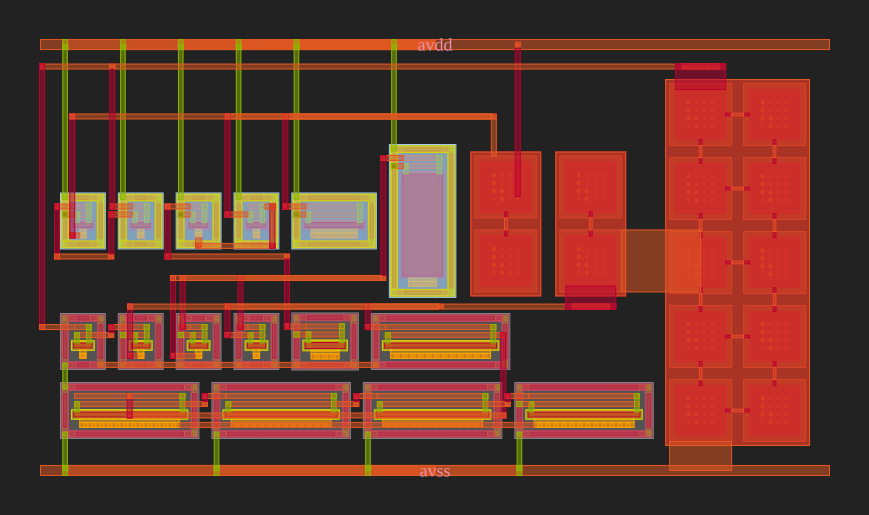

In [8]:
# stdp_comp.show()
display_component(stdp_comp, scale = 1,path=".")

In [9]:
# =========================================================================
# 5. ADD MET2 PHYSICAL PINS AND LABELS FOR LVS
# =========================================================================

# Map port names to their source port objects
pins_to_create = {
    # "avdd": xm1_ref.ports["multiplier_0_source_W"],
    # "avss": xm3_ref.ports["multiplier_0_source_W"],
    "nvpost": xm2_ref.ports["multiplier_0_gate_E"],
    "nvpre": xm8_ref.ports["multiplier_0_gate_E"],
    "vpost": xm12_ref.ports["multiplier_0_gate_E"],
    "vpre": xm3_ref.ports["multiplier_0_gate_E"],
    "vb_idep": xm16_ref.ports["multiplier_0_gate_E"],
    "vb_itd": chain_refs[0].ports["multiplier_0_gate_W"],
    "vb_itp": xm17_ref.ports["multiplier_0_gate_E"],
    "vb_pot": xmcm_1_ref.ports["multiplier_0_gate_E"],
    "vw": cw_ref.ports["row0_col0_top_met_E"],
}

for pin_name, port in pins_to_create.items():
    # Extract center position, size, and orientation from port object
    center = port.center
    width = port.width
    height = port.width  # Standard square pin area around the port center

    # 1. Add pin rectangle shape on met2_pin
    stdp_comp.add_polygon(
        [
            (center[0] - width / 2, center[1] - height / 2),
            (center[0] + width / 2, center[1] - height / 2),
            (center[0] + width / 2, center[1] + height / 2),
            (center[0] - width / 2, center[1] + height / 2),
        ],
        layer=pdk.get_glayer("met2_label") ,
    )

    stdp_comp.add_port(pin_name, center=center, width=1.0, orientation=180, layer=pdk.get_glayer("met2_label"),  port_type="electrical") 

    # 2. Add text label on met2_pin layer for net identity
    stdp_comp.add_label(
        text=pin_name, position=center, layer=pdk.get_glayer("met2_label"), magnification=1.5
    )
    


In [10]:
stdp_comp.pprint_ports()

┏━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ name    ┃ width ┃ center          ┃ orientation ┃ layer    ┃ port_type  ┃
┡━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━┩
│ avdd    │ 1.0   │ [37.49, 43.4]   │ 180         │ [36, 0]  │ electrical │
│ avss    │ 1.0   │ [37.49, 0.8]    │ 180         │ [36, 0]  │ electrical │
│ nvpost  │ 1.0   │ [8.35, 24.31]   │ 180         │ [36, 10] │ electrical │
│ nvpre   │ 1.0   │ [19.93, 24.31]  │ 180         │ [36, 10] │ electrical │
│ vpost   │ 1.0   │ [19.93, 12.255] │ 180         │ [36, 10] │ electrical │
│ vpre    │ 1.0   │ [2.56, 12.255]  │ 180         │ [36, 10] │ electrical │
│ vb_idep │ 1.0   │ [37.65, 19.46]  │ 180         │ [36, 10] │ electrical │
│ vb_itd  │ 1.0   │ [33.05, 12.255] │ 180         │ [36, 10] │ electrical │
│ vb_itp  │ 1.0   │ [29.69, 24.31]  │ 180         │ [36, 10] │ electrical │
│ vb_pot  │ 1.0   │ [27.89, 12.2]   │ 180         │ [36, 10] │ electrical │
│ vw      │ 1.0   │ [66.58, 6.8]    │ 180         │ [36, 10] │ electrical │
└─────────┴───────┴─────────────────┴─────────────┴──────────┴────────────┘

2026-08-10 21:07:38.043 | WARNING  | gdsfactory.klive:show:48 - Could not connect to klive server. Is klayout open and klive plugin installed?


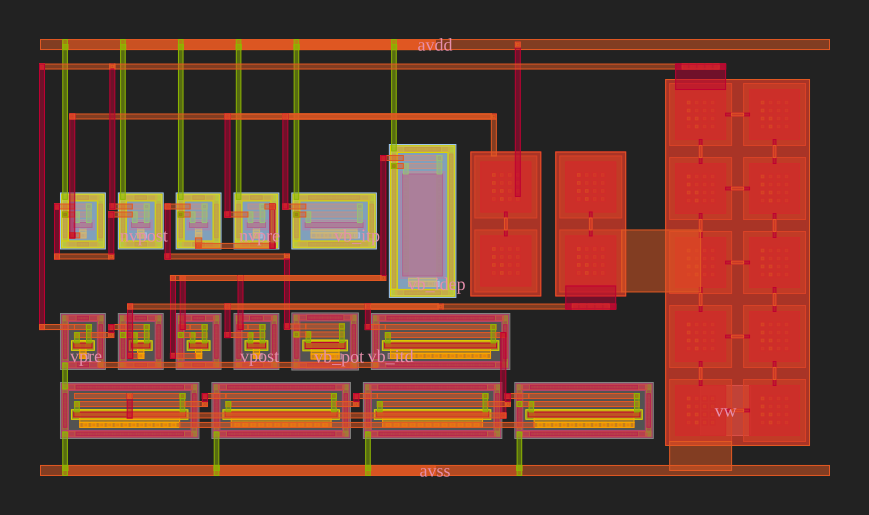

In [11]:
stdp_comp.show()
display_component(stdp_comp, scale = 1,path=".")

In [12]:
# -------------------------------------------------------------------
# Adding tap ring. Discarded
# -------------------------------------------------------------------
# shift_amount = -prec_center(stdp_comp.flatten())[0];
# shift_vertical = -prec_center(stdp_comp.flatten())[1];
# tap_ring = tapring(pdk, enclosed_rectangle=evaluate_bbox(stdp_comp.flatten(), padding=pdk.get_grule("nwell")['min_separation']+1));
# tring_ref = stdp_comp << tap_ring;
# tring_ref.movex(destination=shift_amount).movey(destination=shift_vertical);
# component = component_snap_to_grid(rename_ports_by_orientation(stdp_comp))
# display_component(stdp_comp, scale = 1,path=".")
# stdp_comp.show()

In [13]:
evaluate_bbox(stdp_comp)

(79.08, 43.6)

In [14]:
stdp_est_area = evaluate_bbox(stdp_comp)[0] * evaluate_bbox(stdp_comp)[1]
stdp_est_area

3447.888

In [15]:
stdp_comp.name="stdp"
drc_result = gf180.drc_magic(stdp_comp, stdp_comp.name)

2026-08-10 21:07:38.248 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp6wko0w2l/stdp.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmp6wko0w2l/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0

In [16]:
#At first, we need to properly set PDKPATH and PDK_ROOT 

print("Making sure your environment varriables are still correctly set")
print(" I am using PDK in: ",os.environ['PDK_ROOT'],"\n PDK name: ",os.environ['PDK'],"\n The PDK files are at: ",os.environ['PDKPATH'])

Making sure your environment varriables are still correctly set
 I am using PDK in:  /foss/pdks 
 PDK name:  gf180mcuD 
 The PDK files are at:  /foss/pdks/gf180mcuD


In [17]:
import os
from pathlib import Path
import tempfile

In [18]:
magicrc_file = Path(os.environ['PDKPATH']) / "libs.tech" / "magic" / f"{os.environ['PDK']}.magicrc"
design_name=stdp_comp.name
path_to_dir = "/foss/designs/libs/snn_analog/stdp/"

pex_path = path_to_dir + f"{design_name}.spice"
gds_path = path_to_dir + f"{design_name}.gds"

stdp_comp.write_gds(str(gds_path))
    
magic_script_content = f"""
drc off            
gds flatglob *\\$\\$*
gds read {gds_path}

flatten {design_name}
load {design_name}
select top cell
extract do local
extract all
ext2sim labels on
ext2sim
extresist tolerance 10
extresist
ext2spice lvs
ext2spice cthresh 0
ext2spice extresist on
ext2spice -o {str(pex_path)}
exit
"""

with tempfile.NamedTemporaryFile(mode='w', delete=False) as magic_script_file:
    magic_script_file.write(magic_script_content)
    magic_script_path = magic_script_file.name
    
magic_cmd = f"bash -c 'magic -rcfile {magicrc_file} -noconsole -dnull < {magic_script_path}'",
magic_subproc = subprocess.run(
    magic_cmd, 
    shell=True,
    check=True,
    capture_output=True
)

magic_subproc_code = magic_subproc.returncode
magic_subproc_out = magic_subproc.stdout.decode('utf-8')
print(magic_subproc_out)



2026-08-10 21:07:38.688 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/stdp/stdp.gds'



Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using GDS-II Release 6.0
Library name: library
Reading "stdp".
Reading "cw".
Reading "c_route_

In [19]:
import glob
extensions = [
            "els"
            "*.gds",
            "*.ext",
            "*.res.ext",
            "*.lvs.rpt",
            "*_lvs.rpt",
            "*.nodes",
            "*.sim",
            "*.pex.spice",
            "*_pex.spice"
            ]
files_to_delete = []
for ext in extensions:
    files_to_delete.extend(glob.glob(ext))
    
# Delete the files
for file_path in files_to_delete:
    try:
        os.remove(file_path)
        print(f"Deleted: {file_path}")
    except OSError as e:
        print(f"Error deleting {file_path}: {e}")

Deleted: L_route_70197ec4.ext
Deleted: straight_route_3e7c72c9.ext
Deleted: L_route_19c8dcf0.ext
Deleted: L_route_e52df609.ext
Deleted: compass_e1e0dc30.ext
Deleted: straight_route_1be9fc01.ext
Deleted: via_stack_22f48a44$3.ext
Deleted: L_route_008dc9ca.ext
Deleted: L_route_bf7286ae.ext
Deleted: c_route_29f44436.ext
Deleted: compass_e1e0dc30$1.ext
Deleted: L_route_9e0c10e9.ext
Deleted: straight_route_ee1f5cf6.ext
Deleted: c_route_a9f84c2e.ext
Deleted: c_route_0c3391f9.ext
Deleted: straight_route_0dfaefd2.ext
Deleted: via_stack_22f48a44$13.ext
Deleted: stdp.ext
Deleted: straight_route_32ea8b1d.ext
Deleted: L_route_75fcf1e1.ext
Deleted: xm12.ext
Deleted: via_stack_22f48a44$10.ext
Deleted: straight_route_1fae1140.ext
Deleted: xm8.ext
Deleted: xm9.ext
Deleted: cpot.ext
Deleted: straight_route_f3c2e732.ext
Deleted: straight_route_81952055.ext
Deleted: xm17.ext
Deleted: straight_route_4cec2025.ext
Deleted: L_route_507a0ee8.ext
Deleted: L_route_42664837.ext
Deleted: straight_route_d77458f6.ex

In [20]:
gf180.lvs_netgen(
    layout=stdp_comp,
    design_name = stdp_comp.name,
    pdk_root = Path(os.environ['PDKPATH']),
    lvs_setup_tcl_file = Path(os.environ['PDKPATH']) / "libs.tech" / "netgen" / f"{os.environ['PDK']}_setup.tcl",
    netlist = Path(str(path_to_dir + "stdp_sch.spice")),
    output_file_path =  Path(str(path_to_dir))
)



2026-08-10 21:07:39.531 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpwhlufwa7/stdp.gds'


using user specified pdk_root, will search for required files in the specified directory

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using

{'magic_subproc_code': 0,
 'netgen_subproc_code': 0,
 'result_str': 'LVS run succeeded\nErrors found in LVS report: /tmp/tmpwhlufwa7/stdp_lvs.rpt'}